## Satellite Simulation Notebook
- Author Brandon Engelbrecht

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%reload_ext autoreload

In [3]:
import gnss_models_v3 as gm
import pickle
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm
import time

In [4]:
'/users/bengelbrecht/PhD_Work/Satellite_Code/test2/1551055211_level6_mask/1551055211_katdal_info.p'

'/users/bengelbrecht/PhD_Work/Satellite_Code/test2/1551055211_level6_mask/1551055211_katdal_info.p'

In [5]:
class S34:
    """
    An object which calculates the comparison between the Observational TOD and the simulated TOD.
    The TOD can be sliced in both time and frequency for the users preferance.
    
    Requirements:
        s1_data_loc - Location of the re-calibration data
        s2_data_loc - Location of the angualr seperation maps of the satellite
        bias_choice_loc - Location of the bias choice parameters for the satellites
    """
    def __init__(self, 
                 file_name = None, 
                 s1_data_loc = '/users/bengelbrecht/PhD_Work/Satellite_Code/test2/1551055211_level6_mask/', 
                 s2_data_loc = '/users/bengelbrecht/PhD_Work/Satellite_Code/test2/1551055211_level6_mask/',
                 bias_choice_loc = '/users/bengelbrecht/PhD_Work/Satellite_Code/test2/1551055211_level6_mask/'):
        
        self.file_name = file_name
        self.s1_data_loc = s1_data_loc
        self.s2_data_loc =  s2_data_loc
        self.bias_choice_loc = bias_choice_loc
        
        
        self.katdal_info = self.get_katdal_info(s1_data_loc)
        
        #------------------------------------------------------
        # Getting the outputs of katdal info:
        self.nd_s, self.nd_s0, self.frequency, self.nd_s0_pos, self.timestamps, self.nd_s0_coords = [self.katdal_info[i] for i in self.katdal_info.keys()]
        '''
        nd_s - noise diode scan in period
        nd_s0 - noise diode off scan in period
        frequency - frequency range or band
        nd_s0_pos - index of noise diode off in scan perid
        timestamps - time flow od the data
        nd_s0_coords - azimuth and elevation of the data
        '''
        #------------------------------------------------------

        
        
    def excecute(self, file_bias_choice='bias_choices', obs_time_start=None, 
                 obs_time_end=None, obs_frequency_start=None, obs_frequency_end=None):
        '''
        A function which excutes all the function currently available to us. 
        A means to avoid initializing them.
        
        file_bias_choice - name of the file
        obs_time_start/end - the time slice of the data and simulation
        obs_frequency_start/end - the frequency start and end for the data and simulations
        '''
        
        # Sets the frequency band
        self.frequency_band = self.get_frequency_information()
        
        # Observational data
        self.calibration_data, self.calibration_data_original, self.calibration_data_noise = self.get_calibration_data()
        
        # Satellite positioning
        self.satellite_type, self.satellite_angle = self.get_satellite_angle_seperation()  
        
        # Satellite TOD
        self.satellite_TOD, self.satellite_SED = self.get_gnss_simulaton()
        
        # Calibration data slice
        self.calibration_data_slice, self.calibration_noise_slice, self.time_idx, self.frequency_idx = self.get_data_slice(start_time=obs_time_start, 
                                                                end_time=obs_time_end, 
                                                                start_frequency=obs_frequency_start, 
                                                                end_frequency=obs_frequency_end)
        # Satellite simulation slice
        self.simulation_slice, self.simulation_TOD_slice, self.bias_choice, self.satellite_TOD_slice = self.get_simulation_slice(file_bias_choice=file_bias_choice)
    
    
    
    def plotting(self, individual=None, logger=None, tod_limit=None, save_file=None, suffix=None):
        """
        Plotting various plots: 
        1. The 1D Simulation model vs the Observational data 
        2. The Time-Ordered-Data for the obsevational data
        3. The Time-Ordered-Data for the simualtion data
        
        Parameters:
        individual - If "None" will plot the combined model vs observation data. If "not None" will show the indivdiual satellite componants
        logger - If "None" plots will be in linear scale. If "not None" plots will be in log scale
        tod_limit - The vmin and vmax for both TOD maps
        save_file - If "not None" file will be saved for all plots. Plots name will include both time and freqeuncy positions.
        suffix - If "not None" plot name will contain user input suffix
        
              
        """
        self.slice_plot_frequency = self._get_slice_plot_(ALL=individual, save_file=save_file)
        self.TOD_map = self._get_TOD_maps_(log_values=logger, vlimits=tod_limit, save_file=save_file)
        self.sat_sim_map = self._get_TOD_sim_maps_(log_values=logger, vlimits=tod_limit, save_file=save_file)
    
        
    
    def get_katdal_info(self, s1_data_loc):
        '''
        Obtain KATDAL information regarding the data set such as the frequency and the noise diodes in scanning/no diode fired
        '''
        
        try:
            fname = self.file_name
            data = pickle.load(open(self.s1_data_loc+fname+'_katdal_info.p', 'rb'))
            
            return data
            
        except Exception as e:
            print fname+'-Katdal Information not found :('
        
        
        
        
    def get_frequency_information(self):
        '''
        Function for the frequency start and end postion
        !!! Should add some extra stuff here regarding the printing of the freqeuncy bands.
        For not fixed
        '''
        f_start_idx = 600
        f_end_idx = 2482
        f_band = self.frequency[f_start_idx:f_start_idx+f_end_idx]
        
        return f_band
        
               
        
    def get_calibration_data(self):
        '''
        Obtain the calibrated TOD for the temperature and the noise
        '''
        
        try:
            fname = self.file_name
            data = pickle.load(open(self.s1_data_loc+fname+'_average_TOD.p'))
            
            Temp_tod = data['TOD Avg'].T
            Temp_noise = data['BG Model'].T
            Temp_res = Temp_tod - Temp_noise     # Getting the BG model to be added to the simualtions instead

            return Temp_res, Temp_tod, Temp_noise

        except Exception as e:
            print fname+'-Calibration Information not found :('
       
        
           
    def get_satellite_angle_seperation(self):
        '''
        Obtain the angular seperation results for the various satellites
        This takes 9sec to read in
        '''
        try:
            fname = self.file_name
            data = pickle.load(open(self.s2_data_loc+fname+"_ang_sep_extra.p", "rb"))
            
            Satellite_type = data["sat_name"]     # Contains the names of the constellations
            Satellite_angle = data["angular"]     # Contains the angular seperation maps
            
            return Satellite_type, Satellite_angle
        
        except Exception as e:
            print fname+'-Satellite angular seperation not found :('
                        
            
        
    def get_gnss_simulaton(self):
        '''
        Get the TOD maps of the satellites and our data.
        For all the different types of satellites
        '''
        from gnss_models_v3 import TOD_sats
        
        satellite_TOD = np.array([gm.TOD_sats(name_tod=satellite_name, 
                                     fname=self.file_name, 
                                     frequency_tod=self.frequency_band, 
                                     beam_model=self.satellite_angle[i])[0] for i, satellite_name in enumerate(self.satellite_type)])

        
        satellite_SED = np.array([gm.TOD_sats(name_tod=satellite_name, 
                                     fname=self.file_name, 
                                     frequency_tod=self.frequency_band, 
                                     beam_model=self.satellite_angle[i])[1] for i, satellite_name in enumerate(self.satellite_type)])
        
        return satellite_TOD, satellite_SED
    
    
    
    #-------------------------------------------S4-----------------------------------------------------------------
    #                                         SECTION 4
    #-------------------------------------------S4-----------------------------------------------------------------

    
    
    def get_data_slice(self, start_time=None, end_time=None, start_frequency=None, end_frequency=None):
        '''
        Slicing the claibrated observational data and noise in the time and frequency domain.
        start_time - the beginning of the scan period - 774 seconds
        end_time - the end of the scan period - 6474 seconds
        start_frequency - beginning of the freqeuncy band usually 981 MHz
        end_frequency - end of the frequency band usually 1499.9
        '''
    
        # Slicing in the time domain:
        if start_time==None and end_time==None:
            st_pos, et_pos = 0,-1
        else:
            st_pos = (np.where(self.nd_s0 > start_time)[0][0])
            et_pos = (np.where(self.nd_s0 > end_time)[0][0])
            print 'Time between: '+str(self.nd_s0[st_pos])+' and '+str(self.nd_s0[et_pos])+' in seconds\n'
            
            
        # Slicing in the frequency domain:
        if start_frequency==None and end_frequency==None:
            sf_pos, ef_pos = 0,-1
        else:
            sf_pos = (np.where(self.frequency_band > start_frequency)[0][0])
            ef_pos = (np.where(self.frequency_band > end_frequency)[0][0])
            print 'Frequency between: '+str(self.frequency_band[sf_pos])+' and '+str(self.frequency_band[ef_pos])+' in MHz\n'

                    
        calibration_data_slice = self.calibration_data[sf_pos:ef_pos, st_pos:et_pos]
        calibration_noise_slice = self.calibration_data_noise[sf_pos:ef_pos, st_pos:et_pos]
        
        return calibration_data_slice, calibration_noise_slice, (st_pos, et_pos), (sf_pos, ef_pos)
    
    
    
    
    def _average_over_time_(self, x):
        '''
        Function to return the averaged time response
        from a 2d shape, time should be in the first axis
        '''
        return np.mean(x, axis=0)

    
    
    def _average_over_frequency_(self, x):
        '''
        Function to return the averaged frequency response
        from a 2d shape
        '''
        return np.mean(x, axis=1)
    
    
    
    
    def get_simulation_slice(self, file_bias_choice=None):
        '''
        Slicing the simualted satellite data with the index values obtained from the 'get_data_sliced'
        '''
        
        satellite_TOD_slice = self.satellite_TOD[:, self.frequency_idx[0]:self.frequency_idx[1], self.time_idx[0]:self.time_idx[1]]    # This is needs to spliced with the above slice
        
#         bg_model_added = self.calibration_data_noise[self.frequency_idx[0]:self.frequency_idx[1], self.time_idx[0]:self.time_idx[1]] # This is the bg_model being added to the observational data for the simulations
        
        if file_bias_choice!=None:
            bias_choice = np.loadtxt(fname=self.bias_choice_loc+(file_bias_choice)+'.txt', delimiter=' ')
            
        else:
            print  'Enter the '+str(len(self.satellite_type)+1)+' bias choices for the following: '
            print ', '.join(self.satellite_type) +', noise'
            bias_choices_input = raw_input('Enter elements of a list separated by space ')
            bias_choice = [int(i) for i in bias_choices_input.split()]
        
        
        gnss_bias_model = np.nansum([satellite_TOD_slice[i]*bias_choice[i] for i in range(len(satellite_TOD_slice))], 0) #+ bias_choice[-1] Don't require this amplitude
        
        
        #Threshold ---------------------------------------
        threshold_k = 400   # K
#         gnss_bias_model_m = np.ma.masked_where(gnss_bias_model >=threshold_k, gnss_bias_model)     # Old method of masking the values, 
                                                                                                     # NOTE have to change the the variable name to have 'xxx_m'
        gnss_bias_model[gnss_bias_model >= threshold_k] = threshold_k                              # Adding a new threshold method 
#         satellite_TOD_slice[satellite_TOD_slice >= threshold_k] = threshold_k                        # Setting the threshold before bias choice
        # ----------------------------------------------
        
        gnss_bias_model_m = gnss_bias_model #+ bg_model_added
                
       
        gnss_bias_model_frequency = self._average_over_frequency_(gnss_bias_model_m)

        
        
        return gnss_bias_model_frequency, gnss_bias_model_m, bias_choice, satellite_TOD_slice
    
    
    # ------------------------------------PLOTS--------------------------------------

    # ------------------------------------PLOTS--------------------------------------

    def _get_slice_plot_(self, ALL=None, save_file=None):
        '''
        Function for plotting the Simulation outputs
        '''
        observation = self._average_over_frequency_(self.calibration_data_slice)
        
        
        plt.figure(figsize=(14, 4))
        plt.title(self.file_name+': Time-['+str(np.round(self.nd_s0[self.time_idx[0]], 2))+'-'+str(np.round(self.nd_s0[self.time_idx[1]], 2))+'] seconds')
        
        plt.plot(self.frequency_band[self.frequency_idx[0]:self.frequency_idx[1]], self.simulation_slice, color='red', label='Model')      
        plt.plot(self.frequency_band[self.frequency_idx[0]:self.frequency_idx[1]], observation, '-', color='black', label='Data')      
        plt.xlabel('Frequency [MHz]')
        plt.ylabel('Temperature [K]')
        if ALL!=None:
            for i in range(len(self.bias_choice)):
                plt.plot(self.frequency_band[self.frequency_idx[0]:self.frequency_idx[1]], 
                         self._average_over_frequency_(self.satellite_TOD_slice[i]) * self.bias_choice[i], 
                         label=self.satellite_type[i]+'  x'+str(self.bias_choice[i]))
            plt.ylim(bottom=1e-2)

        
        plt.yscale('log')
        plt.legend()
        plt.tight_layout()
        if save_file !=None:
            plt.savefig(self.s1_data_loc+self.file_name+'_'+str(np.round(self.nd_s0[self.time_idx[0]], 2))
                        +'_'+str(np.round(self.nd_s0[self.time_idx[1]], 2))+'.png')
            
            # Saving the data to file
            pickle.dump(observation, open(self.s1_data_loc+self.file_name+'_observation_'+str(np.round(self.nd_s0[self.time_idx[0]], 2))+
                            '_'+str(np.round(self.nd_s0[self.time_idx[1]], 2))+'_tod.p', 'wb'))
            
        else:
            plt.show()
        
        
   # Work in progress
    def _get_TOD_maps_(self, log_values=None, vlimits=None, save_file=None):
        '''
        Obtiaing the TOD maps for the different values for the OBSERVATION DATA
        '''
        

        extent = [self.nd_s0[self.time_idx[0]], self.nd_s0[self.time_idx[1]], 
                  self.frequency_band[self.frequency_idx[1]], self.frequency_band[self.frequency_idx[0]]]

        plt.figure()
        plt.title(self.file_name+'-Observation Data: Time-['+str(np.round(self.nd_s0[self.time_idx[0]], 2))+'-'+str(np.round(self.nd_s0[self.time_idx[1]], 2))+'] seconds')
        plt.xlabel('Time [s]')
        plt.ylabel('Frequency [MHz]')
        
        data_slice = self.calibration_data[self.frequency_idx[0]:self.frequency_idx[1], self.time_idx[0]:self.time_idx[1]]
        

        
        if log_values==None:
            if vlimits==None:
                hb=plt.imshow(np.log10(data_slice), extent=extent, aspect='auto')
            else:
                hb=plt.imshow(np.log10(data_slice), extent=extent, aspect='auto', vmin=vlimits[0], vmax=vlimits[1])
            
            cbar = plt.colorbar(hb)
            cbar.set_label(r'log$_{10}$(T) [K]', rotation=270, labelpad=20, y=0.45)

        else:
            if vlimits==None:
                hb=plt.imshow((data_slice), extent=extent, aspect='auto')
            else:
                hb=plt.imshow((data_slice), extent=extent, aspect='auto', vmin=vlimits[0], vmax=vlimits[1])
       
            cbar = plt.colorbar(hb)
            cbar.set_label(r'T [K]', rotation=270, labelpad=20, y=0.45)

        plt.tight_layout()
        if save_file !=None:
            plt.savefig(self.s1_data_loc+self.file_name+'_obs_data_'+str(np.round(self.nd_s0[self.time_idx[0]], 2))+
                        '_'+str(np.round(self.nd_s0[self.time_idx[1]], 2))+'.png')
            
            # Saving the data to file
            pickle.dump(data_slice, open(self.s1_data_loc+self.file_name+'_obs_data_'+str(np.round(self.nd_s0[self.time_idx[0]], 2))+
                            '_'+str(np.round(self.nd_s0[self.time_idx[1]], 2))+'_tod.p', 'wb'))
            
        else:
            plt.show()
            
            
            
   # Work in progress
    def _get_TOD_sim_maps_(self, log_values=None, vlimits=None, save_file=None):
        '''
        Obtiaing the TOD maps for the different values for the SIMULATION DATA
        log_values - 
        '''


        extent = [self.nd_s0[self.time_idx[0]], self.nd_s0[self.time_idx[1]], 
                  self.frequency_band[self.frequency_idx[1]], self.frequency_band[self.frequency_idx[0]]]

        plt.figure()
        plt.title(self.file_name+'-Simulation Data: Time-['+str(np.round(self.nd_s0[self.time_idx[0]], 2))+'-'+str(np.round(self.nd_s0[self.time_idx[1]], 2))+'] seconds')
        plt.xlabel('Time [s]')
        plt.ylabel('Frequency [MHz]')
        
        data_slice = self.simulation_TOD_slice
        

        
        if log_values==None:
            if vlimits==None:
                hb=plt.imshow(np.log10(data_slice), extent=extent, aspect='auto')
            else:
                hb=plt.imshow(np.log10(data_slice), extent=extent, aspect='auto', vmin=vlimits[0], vmax=vlimits[1])
            
            cbar = plt.colorbar(hb)
            cbar.set_label(r'log$_{10}$(T) [K]', rotation=270, labelpad=20, y=0.45)

        else:
            if vlimits==None:
                hb=plt.imshow((data_slice), extent=extent, aspect='auto')
            else:
                hb=plt.imshow((data_slice), extent=extent, aspect='auto', vmin=vlimits[0], vmax=vlimits[1])
       
            cbar = plt.colorbar(hb)
            cbar.set_label(r'T [K]', rotation=270, labelpad=20, y=0.45)

        plt.tight_layout()
        if save_file !=None:
            plt.savefig(self.s1_data_loc+self.file_name+'_sim_data_'+str(np.round(self.nd_s0[self.time_idx[0]], 2))+
                        '_'+str(np.round(self.nd_s0[self.time_idx[1]], 2))+'.png')
            
            # Saving the file
            pickle.dump(data_slice, open(self.s1_data_loc+self.file_name+'_sim_data_'+str(np.round(self.nd_s0[self.time_idx[0]], 2))+
                            '_'+str(np.round(self.nd_s0[self.time_idx[1]], 2))+'_tod.p', 'wb'))
        else:
            plt.show()


        
        
        
    

In [6]:
s_time = time.time()
x1 = S34(file_name='1551055211')
x1.excecute(obs_time_start=2100, obs_time_end=2200, obs_frequency_start=800, obs_frequency_end=1400)
print time.time() - s_time

1551055211-Calibration Information not found :(


TypeError: 'NoneType' object is not iterable

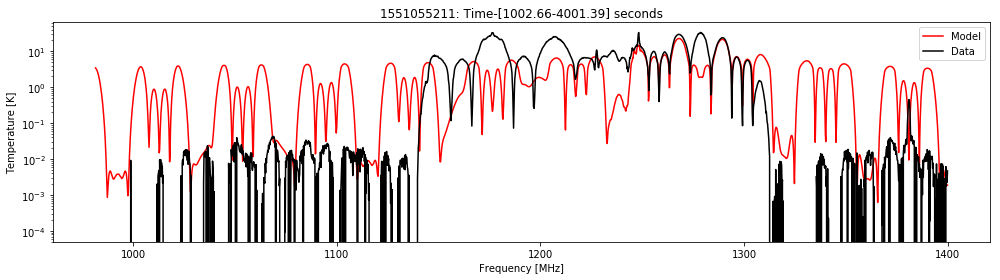

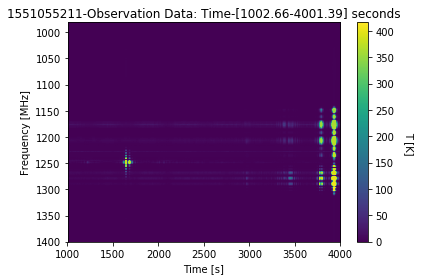

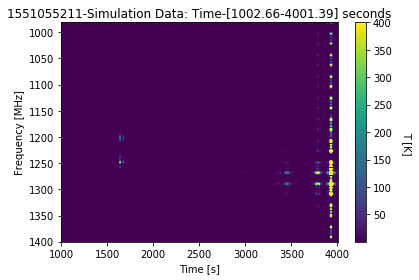

In [23]:
x1.plotting(individual=None, logger=-1, tod_limit=None, save_file=None)

In [104]:
# observation = x1._average_over_frequency_(x1.calibration_data_slice)
# simulation = x1.simulation_slice

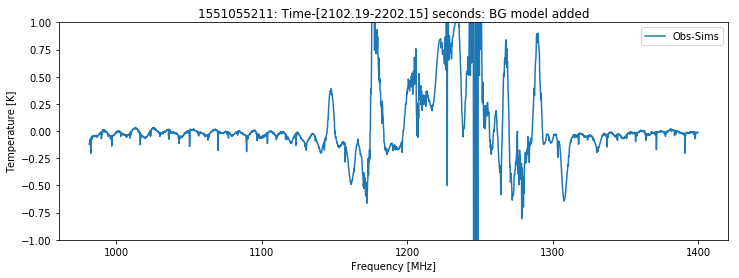

In [89]:
# plt.figure(figsize=(12, 4))
# plt.title(x1.file_name+': Time-['+str(np.round(x1.nd_s0[x1.time_idx[0]], 2))+'-'+str(np.round(x1.nd_s0[x1.time_idx[1]], 2))+'] seconds: BG model added')  
# plt.xlabel('Frequency [MHz]')
# plt.ylabel('Temperature [K]')
# plt.plot(x1.frequency_band[x1.frequency_idx[0]:x1.frequency_idx[1]], observation - simulation, label = 'Obs-Sims')

# plt.ylim(-1,1)

# plt.legend()
# plt.savefig('Jy_mask_plot/'+x1.file_name+'_'+str(np.round(x1.nd_s0[x1.time_idx[0]], 2))+'_'+str(np.round(x1.nd_s0[x1.time_idx[1]], 2))+'_diff_bg_model_added_zoomed.png')
# plt.show()

## -------------------------------------------------------------------------------------------------

###  Plot
To show the difference in the plots between data of satellites before and after the observation day

In [38]:
# data_1_obs = pickle.load(open('data/1551055211_obs_data_2102.19_2202.15_tod.p'))
# data_2_obs = pickle.load(open('data/1551055211_obs_data_2102.19_2202.15_day_after_tod.p'))

# data_1_sim = pickle.load(open('data/1551055211_sim_data_2102.19_2202.15_tod.p'))
# data_2_sim = pickle.load(open('data/1551055211_sim_data_2102.19_2202.15_day_after_tod.p'))

# plt.imshow(data_1_sim - data_2_sim, aspect='auto')
# plt.colorbar()

In [39]:
# plt.plot(x1.frequency_band[x1.frequency_idx[0]:x1.frequency_idx[1]], np.mean(data_1_sim-data_2_sim, axis=1))
# # plt.plot(x1.frequency_band[x1.frequency_idx[0]:x1.frequency_idx[1]], np.mean(data_2_sim, axis=1))


### -----------------------------------------------------------------------

### Looking at the time dependance of the data

In [32]:
f_pos = np.where(x1.frequency_band[x1.frequency_idx[0]:x1.frequency_idx[1]] > 1268)[0][0]

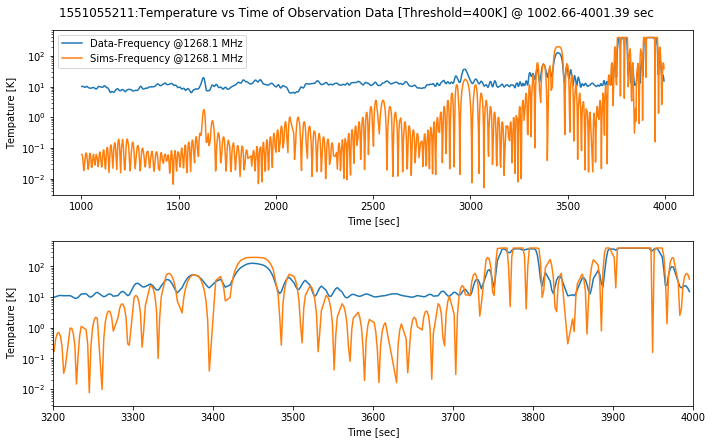

In [33]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 6))
fig.suptitle(x1.file_name+':Temperature vs Time of Observation Data [Threshold=400K] @ '+str(np.round(x1.nd_s0[x1.time_idx[0]],2))+
             '-'+str(np.round(x1.nd_s0[x1.time_idx[1]],2))+' sec', y=1.02)

ax1.plot(x1.nd_s0[x1.time_idx[0]:x1.time_idx[1]], x1.calibration_data_slice[f_pos, :], label='Data-Frequency @'+str(x1.frequency_band[f_pos])+' MHz')
ax1.plot(x1.nd_s0[x1.time_idx[0]:x1.time_idx[1]], x1.simulation_TOD_slice[f_pos, :], label='Sims-Frequency @'+str(x1.frequency_band[f_pos])+' MHz')
ax1.set_xlabel('Time [sec]')
ax1.set_ylabel('Tempature [K]')
ax1.set_yscale('log')
ax1.legend()

ax2.plot(x1.nd_s0[x1.time_idx[0]:x1.time_idx[1]], x1.calibration_data_slice[f_pos, :], label='Data-Frequency @'+str(x1.frequency_band[f_pos])+' MHz')
ax2.plot(x1.nd_s0[x1.time_idx[0]:x1.time_idx[1]], x1.simulation_TOD_slice[f_pos, :], label='Sims-Frequency @'+str(x1.frequency_band[f_pos])+' MHz')
ax2.set_xlabel('Time [sec]')
ax2.set_ylabel('Tempature [K]')
ax2.set_xlim(3200, 4000)
# ax2.set_ylim(0, 500)
ax2.set_yscale('log')

ax1.legend()


fig.tight_layout()
# fig.savefig('Plots2/'+x1.file_name+'_temp_vs_time_@_'+str(x1.frequency_band[f_pos])+'_mhz_@_'+
#             str(np.round(x1.nd_s0[x1.time_idx[0]],2))+'_'+str(np.round(x1.nd_s0[x1.time_idx[1]],2))+'_threshold_400K.png', bbox_inches='tight')
plt.show()

##  ----------------------------------------------------------------------------------------

## 3d data plot of the 2d waterfall plot

In [91]:
# import matplotlib.pyplot as plt
# from matplotlib import cm
# from matplotlib.ticker import LinearLocator
# import numpy as np
# from mpl_toolkits.mplot3d import Axes3D


# # 3D plot of the data for JY

# a = x1.timestamps[x1.nd_s0_pos]
# b = x1.frequency_band
# a, b = np.meshgrid(a, b)
# data_slice = x1.calibration_data


# fig = plt.figure(figsize=(10, 6))

# ax = fig.add_subplot(111, projection='3d')

# surf = ax.plot_surface(a, b, data_slice, cmap=cm.viridis,
#                        linewidth=0, antialiased=False)

# ax.set_title(x1.file_name+'3D maps of Observational Data, after BG subtraction', fontsize=20)

# ax.set_xlabel('Timestamp (sec)', fontsize=10)
# ax.set_ylabel('Frequency [MHz]', fontsize=10)
# ax.yaxis._axinfo['label']['space_factor'] = 3.0
# ax.set_zlabel('Temperature [K]', fontsize=10, rotation = 0)



# # Customize the z axis.
# ax.set_zlim(-2, 20)


# fig.colorbar(surf, shrink=0.5, aspect=5)

# plt.tight_layout()
# plt.savefig('Jy_mask_plot/'+x1.file_name+'_3D_image.png')
# plt.show()

In [25]:
s_time = time.time()
x2 = S34(file_name='1551055211')
x2.excecute(obs_time_start=3300, obs_time_end=3400, obs_frequency_start=1000, obs_frequency_end=1400)
print time.time() - s_time

Time between: 3301.6856923103333 and 3403.6425585746765 in seconds

Frequency between: 1000.2 and 1400.2 in MHz

10.147603035


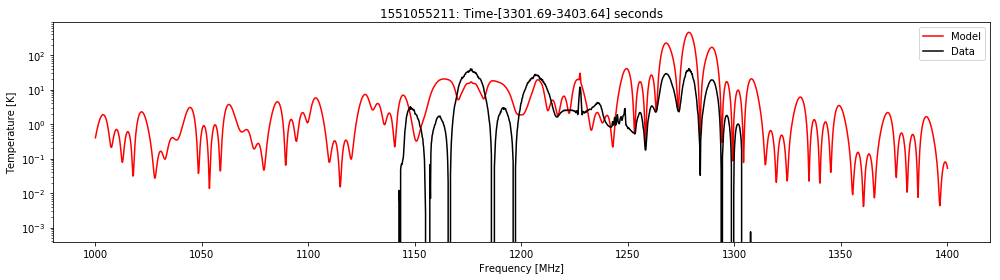

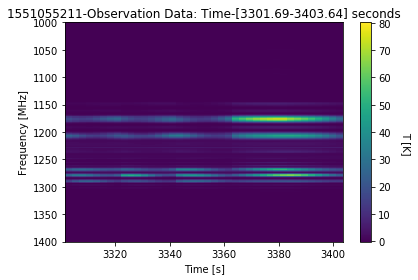

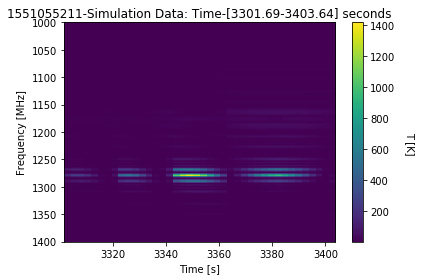

In [26]:
x2.plotting(individual=None, logger=-1, tod_limit=None, save_file=-1)

In [27]:
s_time = time.time()
x3 = S34(file_name='1551055211')
x3.excecute(obs_time_start=1100, obs_time_end=1200, obs_frequency_start=1000, obs_frequency_end=1400)
print time.time() - s_time

Time between: 1102.6160249710083 and 1202.5737371444702 in seconds

Frequency between: 1000.2 and 1400.2 in MHz

10.2847800255


In [33]:
x3.get_data_slice()[0].shape

(2481, 2203)

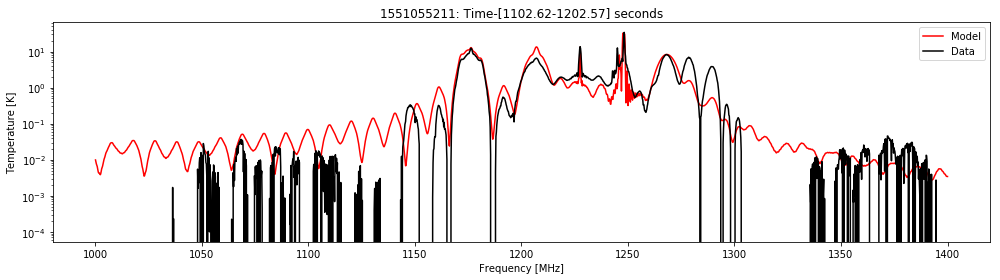

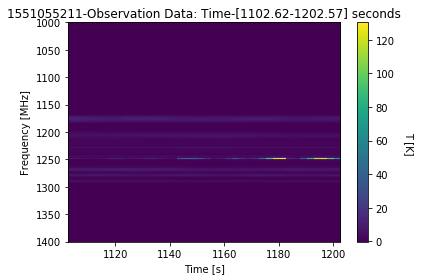

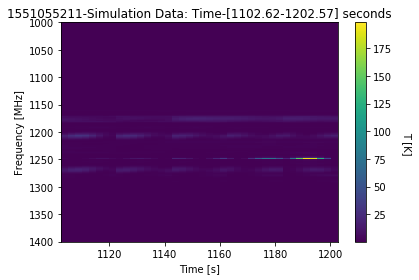

In [28]:
x3.plotting(individual=None, logger=-1, tod_limit=None, save_file=-1)

In [29]:
s_time = time.time()
x4 = S34(file_name='1551055211')
x4.excecute(obs_time_start=4500, obs_time_end=4600, obs_frequency_start=1000, obs_frequency_end=1400)
print time.time() - s_time

Time between: 4501.178238153458 and 4601.135950088501 in seconds

Frequency between: 1000.2 and 1400.2 in MHz

10.1938838959


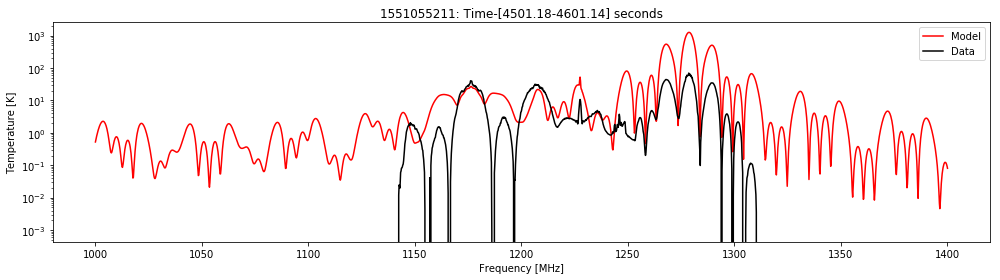

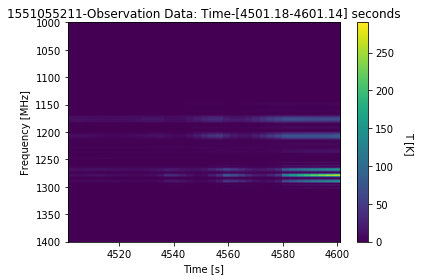

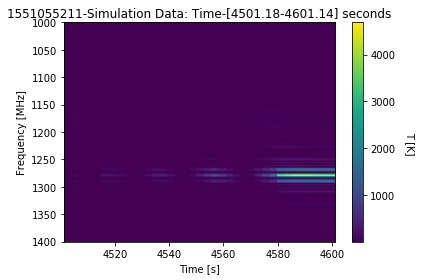

In [30]:
x4.plotting(individual=None, logger=-1, tod_limit=None, save_file=-1)